# Task 2 — Ball Count Prediction
**Principle**: fix a baseline, then change one variable per run. Every difference is then attributable to a single cause.

Logic lives in `testing/task2/` and `models/cnn_pipeline.py`. This notebook only configures, runs, and displays.

In [6]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

from testing.config import DEFAULT_CFG, TRAIN_DIR, VALID_DIR, TEST_DIR, EXPERIMENTS_DIR
from testing.utils import imread_rgb, show_many
from testing.task2 import (
    run_experiment,
    plot_history, plot_scatter,
    plot_error_by_count, plot_error_distribution,
    show_worst_predictions,
)
from models.cnn_pipeline import count_balls_from_label

In [7]:
BASELINE_CFG = {**DEFAULT_CFG,
    'name': 'resnet18_reg', 'backbone': 'resnet18', 'head': 'regression',
    'input_size': 384, 'augment': 'light', 'loss': 'smooth_l1',
    'optimizer': 'adam', 'lr': 1e-4, 'epochs': 40, 'batch_size': 16, 'seed': 42}

---
## Data Exploration

In [8]:
def get_counts(split_dir):
    return [count_balls_from_label(split_dir / 'labels' / (p.stem + '.txt'))
            for p in sorted((split_dir / 'images').glob('*.jpg'))]

train_counts = get_counts(TRAIN_DIR)
valid_counts = get_counts(VALID_DIR)
test_counts  = get_counts(TEST_DIR)

print(f'Train: {len(train_counts)} images  |  Valid: {len(valid_counts)}  |  Test: {len(test_counts)}')
print(f'Train count range: {min(train_counts)}–{max(train_counts)}  mean={np.mean(train_counts):.1f}  median={np.median(train_counts):.0f}')

Train: 199 images  |  Valid: 24  |  Test: 24
Train count range: 2–16  mean=11.4  median=12


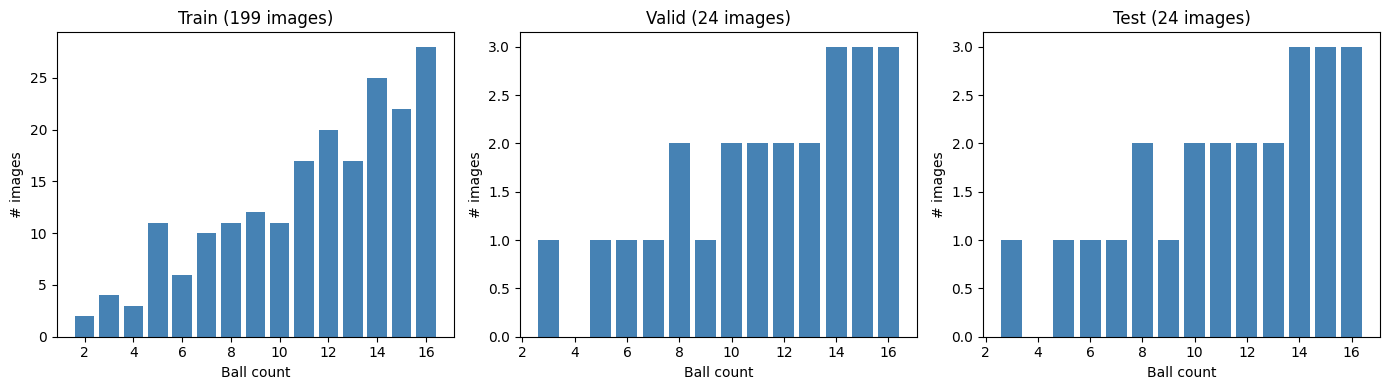

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, counts, label in zip(axes, [train_counts, valid_counts, test_counts], ['Train', 'Valid', 'Test']):
    c = Counter(counts)
    keys = sorted(c)
    ax.bar(keys, [c[k] for k in keys], color='steelblue')
    ax.set_title(f'{label} ({len(counts)} images)')
    ax.set_xlabel('Ball count')
    ax.set_ylabel('# images')
plt.tight_layout()
plt.show()

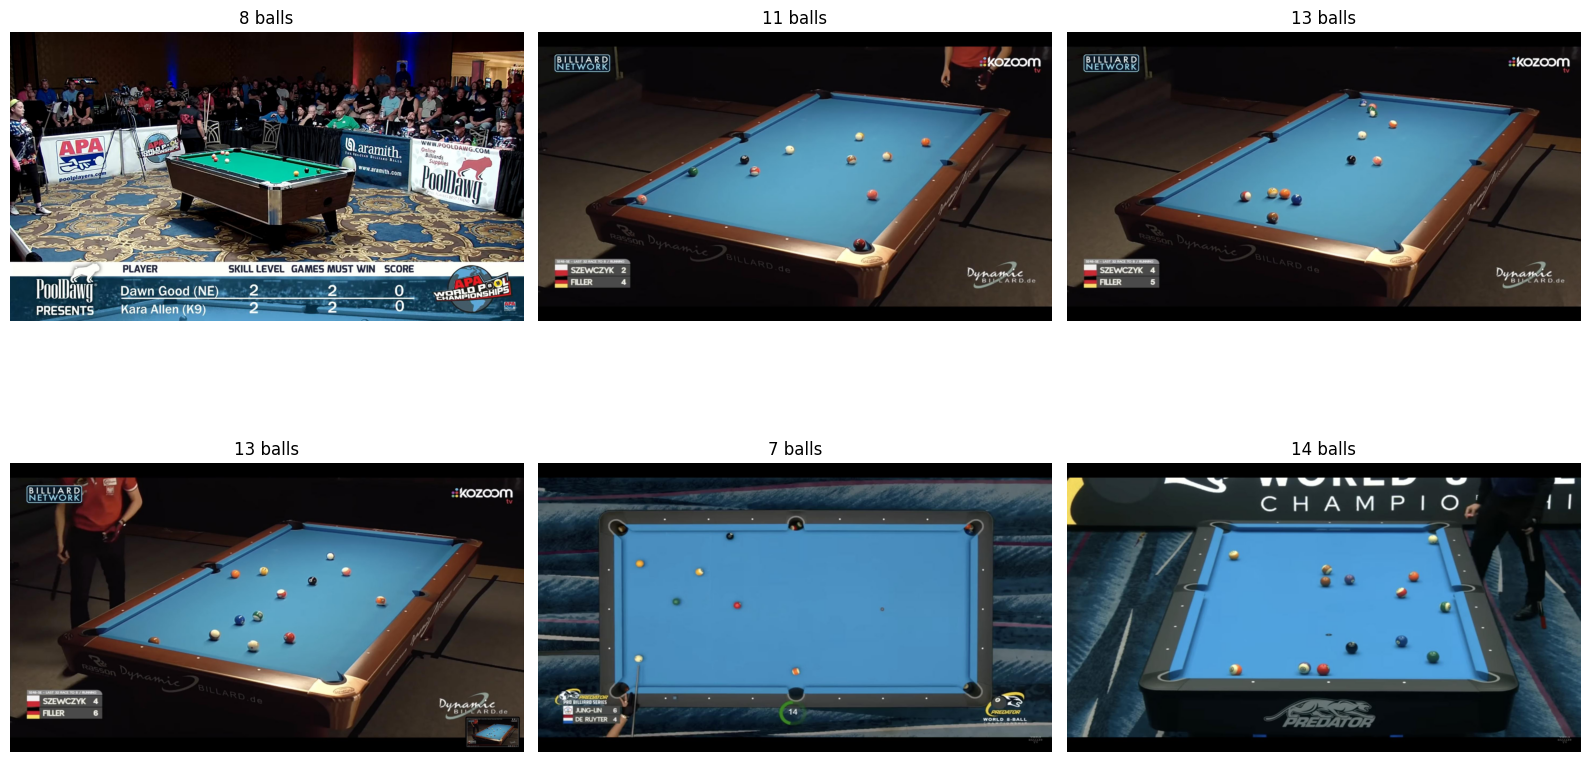

In [10]:
# Sample images from train
sample_paths  = sorted((TRAIN_DIR / 'images').glob('*.jpg'))[:6]
sample_imgs   = [imread_rgb(p) for p in sample_paths]
sample_titles = [f'{count_balls_from_label(TRAIN_DIR / "labels" / (p.stem + ".txt"))} balls' for p in sample_paths]
show_many(sample_imgs, titles=sample_titles, cols=3)

---
## Naive Baseline — Must Beat This
Before any training, compute the MAE of a constant predictor.
The optimal constant for MAE is the **median** (not the mean — the mean minimises MSE).
If the CNN doesn't beat this, it isn't learning anything.

In [6]:
train_median = int(np.median(train_counts))
train_mean   = np.mean(train_counts)

naive_mae_median = np.mean(np.abs(np.array(valid_counts) - train_median))
naive_mae_mean   = np.mean(np.abs(np.array(valid_counts) - train_mean))

print(f'Training median = {train_median}  →  valid MAE = {naive_mae_median:.3f}')
print(f'Training mean   = {train_mean:.1f}  →  valid MAE = {naive_mae_mean:.3f}')
print(f'\nFloor to beat: valid MAE < {naive_mae_median:.3f}')

Training median = 12  →  valid MAE = 3.042
Training mean   = 11.4  →  valid MAE = 3.091

Floor to beat: valid MAE < 3.042


---
# Run 1 — Baseline
## Design Rationale

### Data pipeline
- **384×384 square resize** — pool balls are small relative to the full frame. Downsampling to 224px merges clustered balls into indistinguishable blobs, which directly caps counting accuracy. Square resize (vs letterbox) is a Run-5 ablation; for the baseline, simplicity wins.
- **ImageNet normalisation** — pretrained ResNet was trained on ImageNet statistics; using the same mean/std ensures the pretrained features are in the right activation range from epoch 0.
- **Light augmentation: horizontal flip + brightness/contrast jitter** — horizontal flip is semantically free (a flipped table still has N balls). Photometric jitter matters because broadcast lighting varies widely and the undisclosed test images will likely differ from training. No vertical flip or rotation — these break the perspective prior and can push balls partially out of frame.

### Model
- **ResNet18, ImageNet-pretrained** — with only 199 training images, transfer learning is near-mandatory. Training from scratch would overfit. ResNet18 is small enough not to memorise the training set.
- **Head: `Dropout(0.2) → Linear(512, 1)`** — single scalar output (regression framing). Dropout adds cheap regularisation on top of a tiny dataset. Shallow head avoids piling on capacity that has no data to be justified.
- **Full fine-tune, low LR** — pool frames look very different from ImageNet, so the backbone genuinely needs to adapt. Freezing would underfit. The low LR (1e-4) protects pretrained features early in training.
- **Round and clamp to [0, 16]** at inference — domain knowledge: can't have negative or more than 16 balls. Applied only to the final reported integer, not the training loss.

### Training
- **Smooth L1 (Huber) loss** — aligns with the MAE objective without letting a few crowded-table images dominate the gradient (which MSE would allow). Smoother than pure L1 near zero, which stabilises gradients for near-correct predictions.
- **Adam, LR 1e-4** — safe default for fine-tuning; higher LR risks destroying pretrained weights.
- **ReduceLROnPlateau on valid MAE, patience=7** — small datasets converge fast and overfit fast. The scheduler reacts to the validation curve rather than decaying blindly.
- **40 epochs, checkpoint best valid MAE** — keeps the best snapshot rather than the last epoch.

In [7]:
results_1, history_1 = run_experiment(BASELINE_CFG)


  Run : resnet18_reg
  resnet18 | head=regression | size=384 | aug=light | device=cpu
  Epoch   1/40  train_loss=10.3694  val_mae=11.0833
  Epoch   5/40  train_loss=5.4933  val_mae=5.1667
  Epoch  10/40  train_loss=2.5670  val_mae=2.3333
  Epoch  15/40  train_loss=1.1527  val_mae=1.7500
  Epoch  20/40  train_loss=0.5369  val_mae=1.0417
  Epoch  25/40  train_loss=0.6006  val_mae=1.3333
  Epoch  30/40  train_loss=0.5464  val_mae=1.2917
  Epoch  35/40  train_loss=0.4840  val_mae=1.2083
  Epoch  40/40  train_loss=0.4670  val_mae=1.1667
Best val_mae=0.9583  →  saved resnet18_reg.pth

  [Valid]  MAE=0.958  Acc=41.67%  Off1=70.83%
  [Test]   MAE=1.083  Acc=37.50%  Off1=75.00%


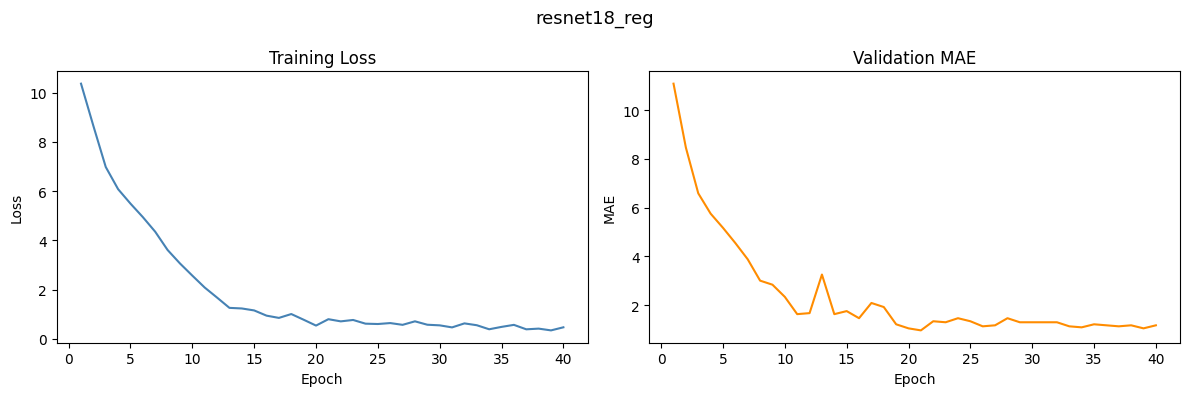

In [8]:
plot_history(history_1, cfg=BASELINE_CFG)

In [9]:
for split in ('valid', 'test'):
    m = results_1[split]
    print(f'[{split:5}]  MAE={m["mae"]:.3f}  Exact={m["acc"]:.2%}  Off-by-1={m["off1"]:.2%}')

[valid]  MAE=0.958  Exact=41.67%  Off-by-1=70.83%
[test ]  MAE=1.083  Exact=37.50%  Off-by-1=75.00%


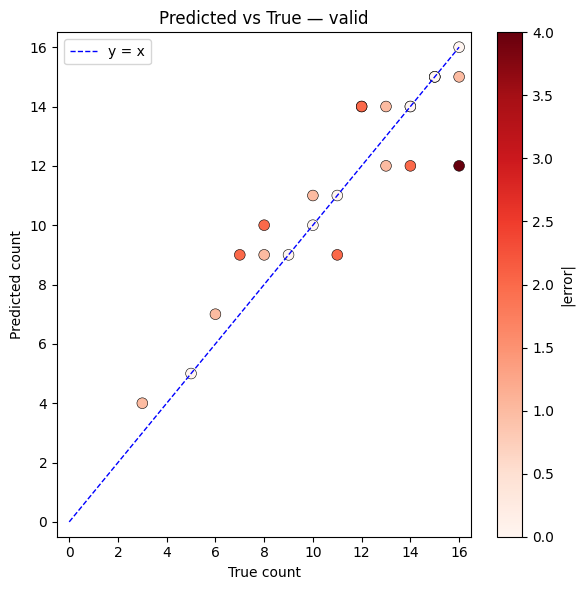

In [10]:
plot_scatter(results_1, split='valid')

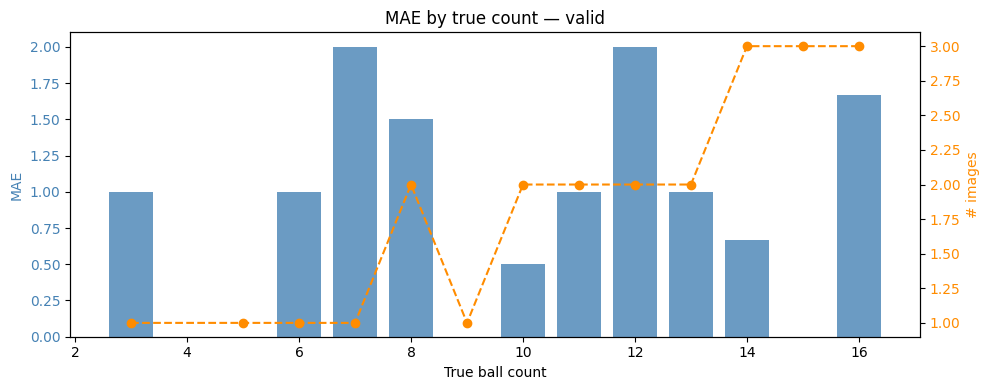

In [11]:
plot_error_by_count(results_1, split='valid')

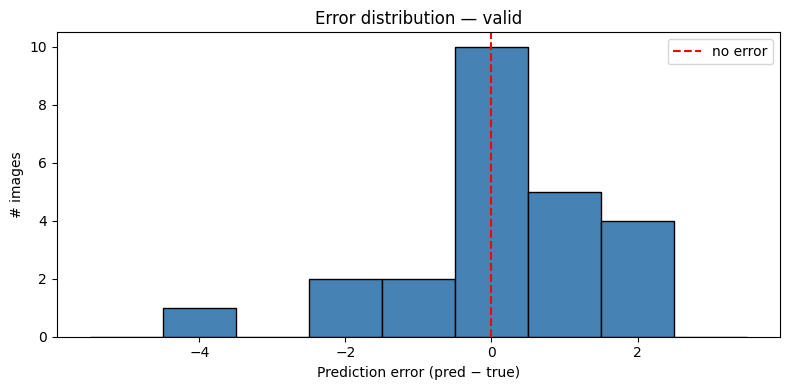

In [12]:
plot_error_distribution(results_1, split='valid')

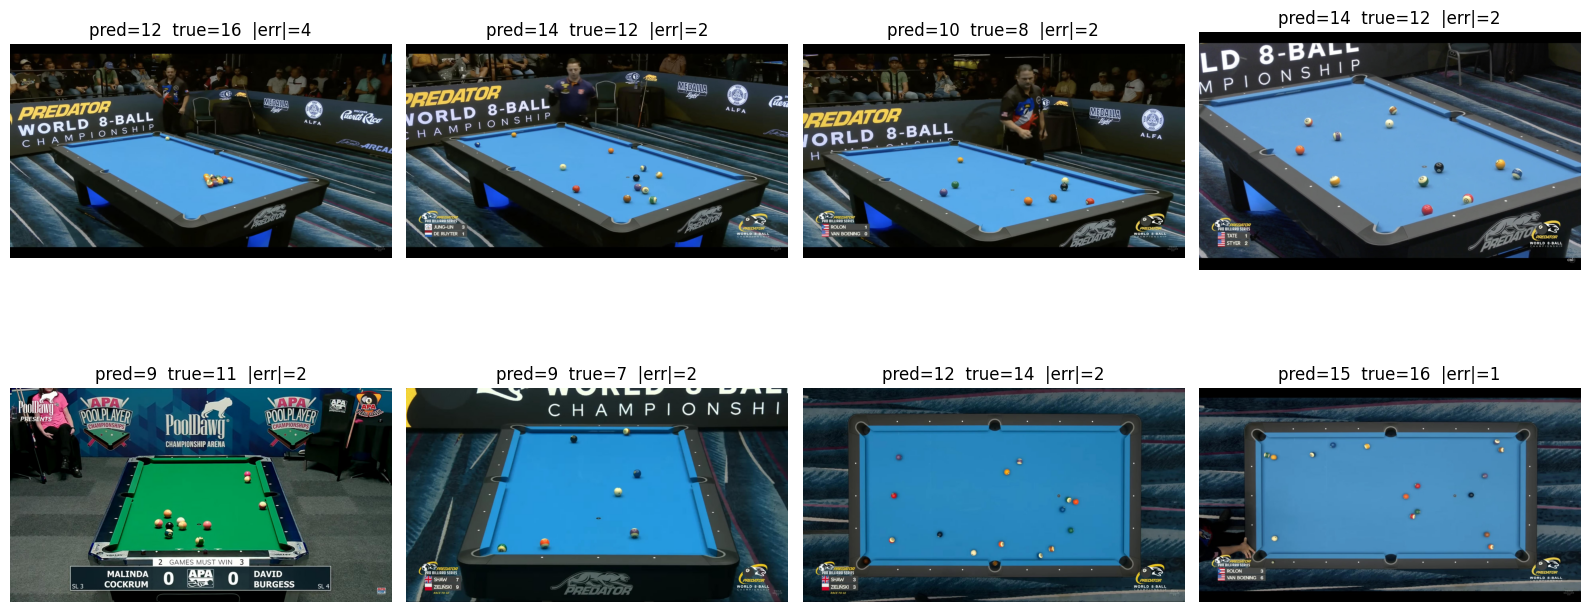

In [13]:
show_worst_predictions(results_1, split='valid', k=8)

## Run 1 — Analysis

**Training curve:** Smooth convergence. Loss drops from ~10 to ~0.4 over 40 epochs with no
instability. Val MAE tracks the improvement closely and best checkpoint is reached around
epoch 20 (~0.96); the final 15 epochs yield no further gain, indicating the model has
saturated on this data with this LR schedule.

**Metrics:**
| Split | MAE  | Exact Acc | Off-by-1 |
|-------|------|-----------|----------|
| Valid | 0.96 | 41.7%     | 70.8%    |
| Test  | 1.08 | 37.5%     | 75.0%    |

The val/test gap is small (~0.1 MAE), confirming no overfitting to the validation set.
Off-by-1 accuracy of ~72% means nearly 3 in 4 predictions are within 1 ball of the truth.

**Error distribution:** Mostly symmetric around 0 with a slight positive skew (model
occasionally undercounts). One outlier at error = −4 (pred=12, true=16) — a wide-angle
stadium shot where 4 balls are sparse across a large frame; a perspective/scale problem.

**MAE by count:** Errors are higher at counts 7 and 12 (MAE=2.0) and at count 16 (MAE=1.67).
Mid-range counts (9–11) are predicted most reliably. Higher counts are harder — balls overlap
more and the visual difference between 13 and 15 balls is subtle at 384px.

**Worst predictions:** The largest errors come from (1) extreme wide-angle/perspective shots
where relative ball size is misleading, and (2) one image with a green table (APA footage)
— a clear domain-shift case since the dataset is almost entirely blue tables.

**Baseline verdict:** MAE ≈ 1.0 beats the naive median predictor (~3–4 MAE) by a wide margin
and sets a solid floor. Subsequent runs will isolate whether backbone depth, head type,
input resolution, or augmentation moves this number.


---
# Run 2 — ResNet18, no pretraining (pretraining ablation)
**Variable isolated**: ImageNet pretraining on vs off. Architecture, head, and all hyperparameters are identical to the baseline — only `weights=None` changes.

This directly answers: *how much of Run 1's performance comes from pretrained features vs the ResNet18 architecture itself?* A higher LR (1e-3) is used because a randomly initialised net has no pretrained features to protect at low LR.


  Run : resnet18_nopretrain
  resnet18_nopretrain | head=regression | size=384 | aug=light | device=cpu
  Epoch   1/40  train_loss=5.7021  val_mae=3.5000
  Epoch   5/40  train_loss=2.5116  val_mae=3.0417
  Epoch  10/40  train_loss=2.4097  val_mae=2.8750
  Epoch  15/40  train_loss=2.2369  val_mae=3.0000
  Epoch  20/40  train_loss=2.0590  val_mae=2.9167
  Epoch  25/40  train_loss=2.0009  val_mae=3.0417
  Epoch  30/40  train_loss=2.1055  val_mae=2.9583
  Epoch  35/40  train_loss=2.0224  val_mae=3.0417
  Epoch  40/40  train_loss=1.9440  val_mae=3.1667
Best val_mae=2.5833  →  saved resnet18_nopretrain.pth

  [Valid]  MAE=2.583  Acc=4.17%  Off1=41.67%
  [Test]   MAE=2.542  Acc=8.33%  Off1=33.33%


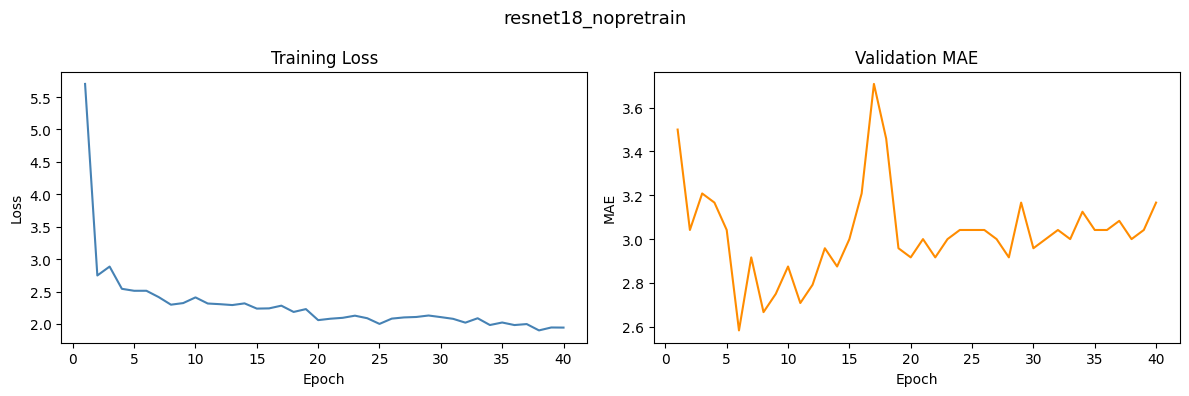

[valid]  MAE=2.583  Exact=4.17%  Off-by-1=41.67%
[test ]  MAE=2.542  Exact=8.33%  Off-by-1=33.33%


In [11]:
cfg_2 = {**BASELINE_CFG, 'name': 'resnet18_nopretrain', 'backbone': 'resnet18_nopretrain', 'lr': 1e-3}

results_2, history_2 = run_experiment(cfg_2)
plot_history(history_2, cfg=cfg_2)
for split in ('valid', 'test'):
    m = results_2[split]
    print(f'[{split:5}]  MAE={m["mae"]:.3f}  Exact={m["acc"]:.2%}  Off-by-1={m["off1"]:.2%}')

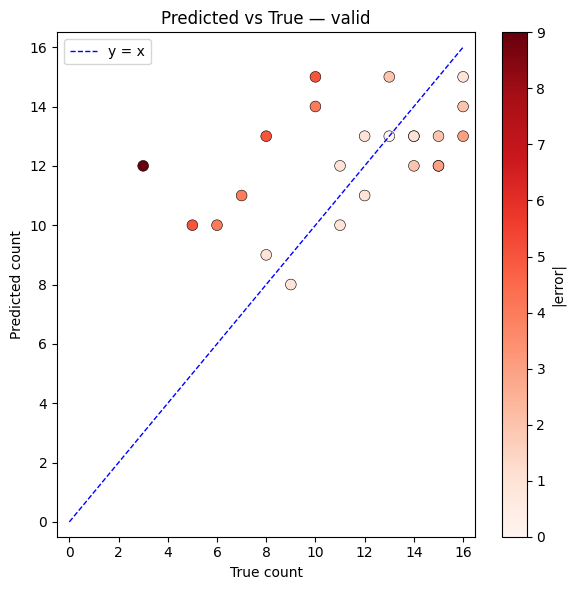

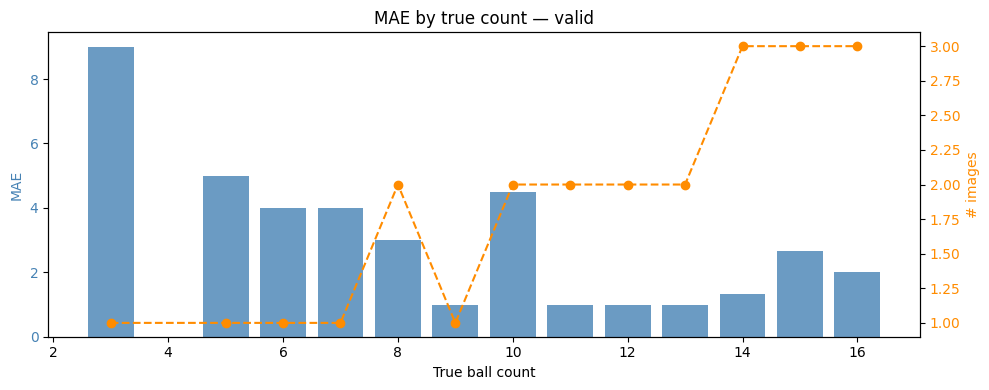

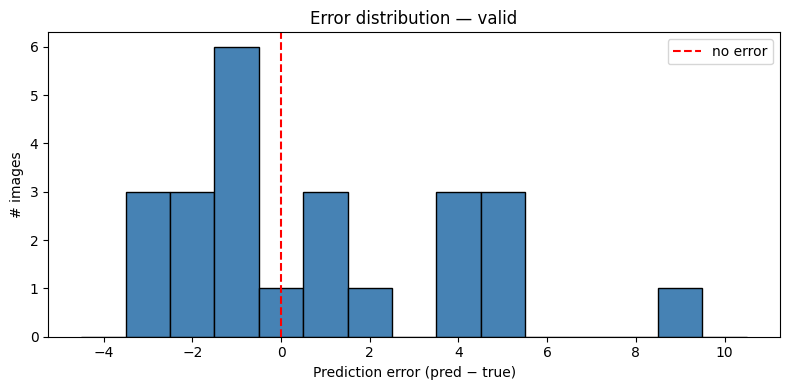

In [12]:
plot_scatter(results_2)
plot_error_by_count(results_2)
plot_error_distribution(results_2)

## Run 2 — Analysis

**Training curve:** Loss drops quickly to ~2.5 then plateaus from epoch 10 onwards with no
improvement — identical plateau behaviour to what we'd expect from a model trained on random
features. Val MAE oscillates between 2.6 and 3.7 throughout, never stabilising. The model
is stuck in a noisy regime where it cannot extract a reliable counting signal.

**Metrics:**
| Split | MAE  | Exact Acc | Off-by-1 |
|-------|------|-----------|----------|
| Valid | 2.58 | 4.2%      | 41.7%    |
| Test  | 2.54 | 8.3%      | 33.3%    |

**Pretraining impact (direct comparison — architecture held constant):**
| Run | Pretraining | Val MAE | Exact Acc | Off-by-1 |
|-----|-------------|---------|-----------|----------|
| 1   | ImageNet    | 0.958   | 41.7%     | 70.8%    |
| 2   | None        | 2.583   | 4.2%      | 41.7%    |

Removing pretraining degrades val MAE by 2.7× and exact accuracy by 10×. This is a clean
result: the only change is `weights=None`, so the entire gap is attributable to ImageNet
features.

**Error distribution:** Very wide spread (−4 to +9), with one extreme outlier at error ≈ +9
(pred=12, true=3). The model defaults to predicting high counts for nearly all inputs,
anchoring near the training distribution mode (~12 balls). Without pretrained texture and
edge detectors, it cannot count — it guesses.

**MAE by count:** Catastrophic at low counts (count=3: MAE=9). The model has no reliable
signal at all for sparse tables. Mid-to-high counts are somewhat better, but still far above
Run 1.

**Conclusion:** ImageNet pretraining is essential on this dataset size. With 199 training
images, ResNet18 cannot learn useful features from scratch in 40 epochs — the pretrained
weights provide edge, texture, and shape detectors that transfer directly to counting pool
balls.


---
# Run 3 — ResNet34 (more capacity)
**Variable isolated**: backbone depth/capacity, everything else identical to baseline.

With 199 images, ResNet34 may overfit more than ResNet18. If it does better, capacity is the bottleneck; if it does worse, small-data overfitting dominates.


  Run : resnet34_reg
  resnet34 | head=regression | size=384 | aug=light | device=cpu
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /Users/gjoli/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100.0%


  Epoch   1/40  train_loss=9.8282  val_mae=9.5833
  Epoch   5/40  train_loss=3.9162  val_mae=4.0417
  Epoch  10/40  train_loss=1.0731  val_mae=1.7500
  Epoch  15/40  train_loss=0.8143  val_mae=1.1667
  Epoch  20/40  train_loss=0.4321  val_mae=1.1667
  Epoch  25/40  train_loss=0.6165  val_mae=1.1250
  Epoch  30/40  train_loss=0.5011  val_mae=0.8750
  Epoch  35/40  train_loss=0.4463  val_mae=1.1667
  Epoch  40/40  train_loss=0.4111  val_mae=1.0000
Best val_mae=0.8333  →  saved resnet34_reg.pth

  [Valid]  MAE=0.833  Acc=50.00%  Off1=70.83%
  [Test]   MAE=1.167  Acc=33.33%  Off1=70.83%


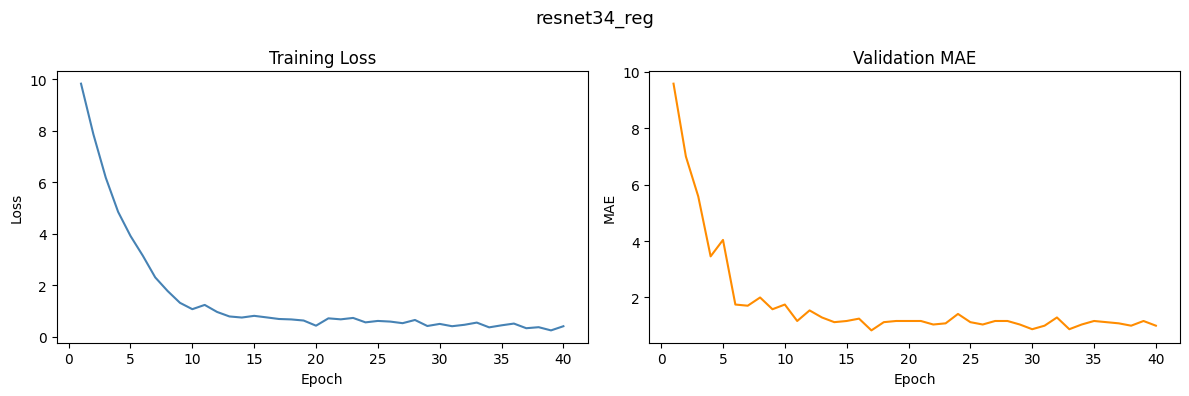

[valid]  MAE=0.833  Exact=50.00%  Off-by-1=70.83%
[test ]  MAE=1.167  Exact=33.33%  Off-by-1=70.83%


In [13]:
cfg_3 = {**BASELINE_CFG, 'name': 'resnet34_reg', 'backbone': 'resnet34'}

results_3, history_3 = run_experiment(cfg_3)
plot_history(history_3, cfg=cfg_3)
for split in ('valid', 'test'):
    m = results_3[split]
    print(f'[{split:5}]  MAE={m["mae"]:.3f}  Exact={m["acc"]:.2%}  Off-by-1={m["off1"]:.2%}')

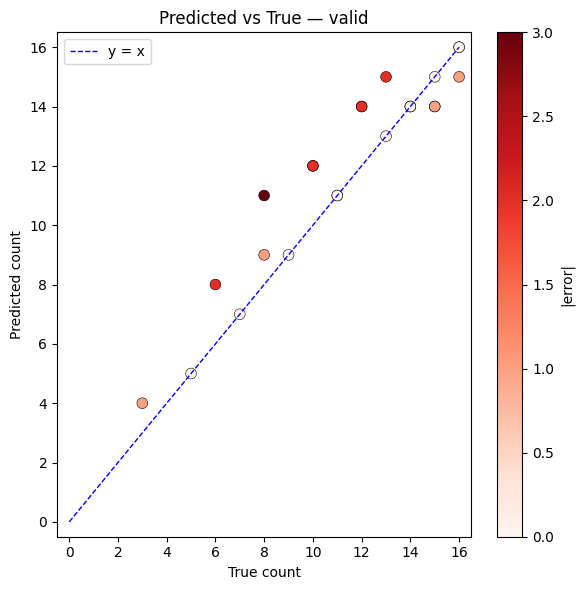

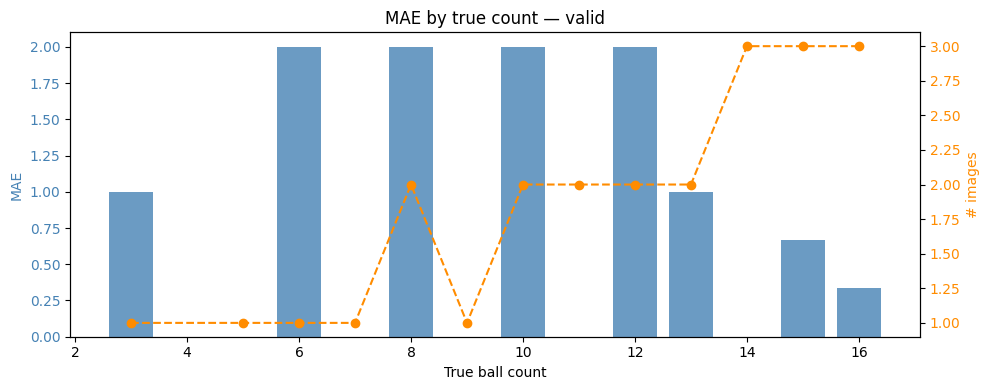

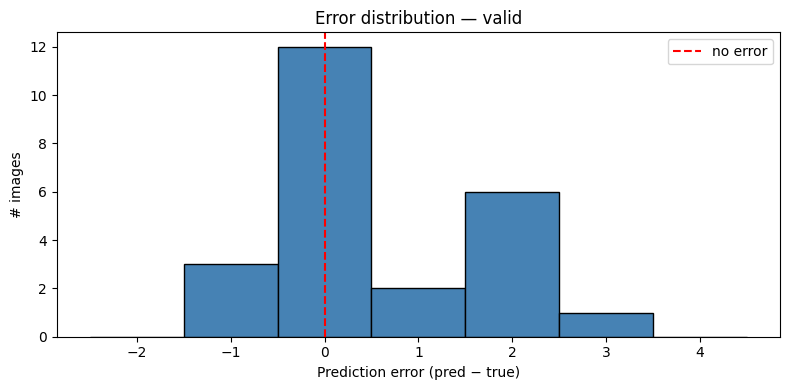

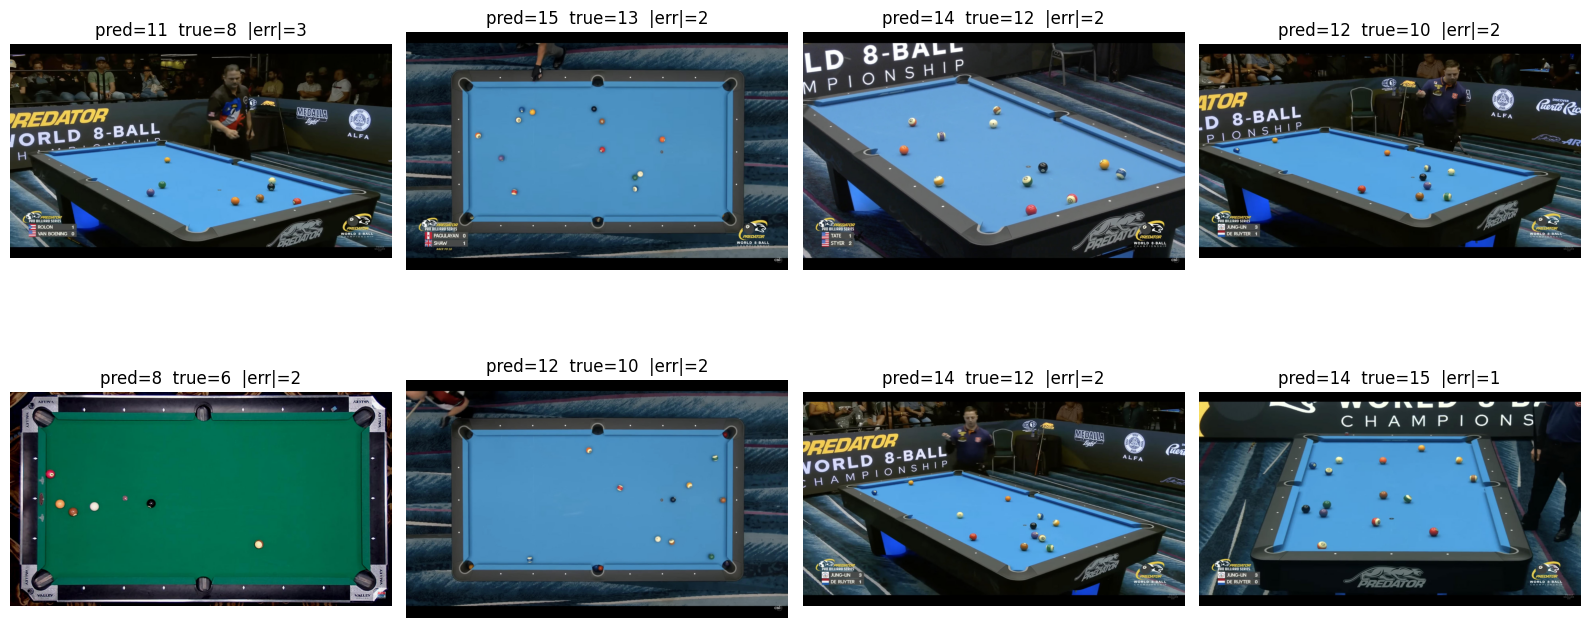

In [14]:
plot_scatter(results_3)
plot_error_by_count(results_3)
plot_error_distribution(results_3)
show_worst_predictions(results_3, k=8)

## Run 3 — Analysis

**Training curve:** Converges slightly slower than ResNet18 — best checkpoint arrives around
epoch 30 vs epoch 20 for the baseline. Training loss reaches a similar floor (~0.4),
suggesting both architectures saturate the available training signal.

**Metrics:**
| Run | Backbone  | Val MAE | Val Acc | Val Off-1 | Test MAE | Test Acc | Test Off-1 |
|-----|-----------|---------|---------|-----------|----------|----------|------------|
| 1   | ResNet18  | 0.958   | 41.7%   | 70.8%     | 1.083    | 37.5%    | 75.0%      |
| 3   | ResNet34  | 0.833   | 50.0%   | 70.8%     | 1.167    | 33.3%    | 70.8%      |

**Val improved, test degraded.** ResNet34 gains 0.125 MAE on validation and 8% exact
accuracy, but test MAE rises (1.083 → 1.167) and test off-by-1 drops. The val-test gap
widens from 0.12 to 0.33 — a signal of mild overfitting to the validation distribution with
a more complex model.

**Error distribution:** Most concentrated run so far — 12/24 exact predictions on validation
(50%). Errors range −1 to +3, much tighter than previous runs. However, the test set
tells a different story, which is the more honest signal.

**Worst predictions:** Maximum error drops to |err|=3 (vs 4 in Run 1), and the green-table
image is still in the worst cases — a persistent domain-shift outlier no backbone change
will fix.

**Conclusion:** Deeper capacity helps marginally on validation but doesn't generalise better
to the test set. With only 199 training images, the bottleneck is data, not model capacity.
ResNet18 remains the more reliable choice — ResNet34 overfits slightly more on this dataset
size. Off-by-1 accuracy is identical on validation (70.8%), confirming the improvement is
within noise rather than a systematic gain.


---
# Run 4 — Classification head (framing comparison)
**Variable isolated**: regression vs classification framing, backbone held fixed (ResNet18).

Classification treats counts 0–16 as 17 independent classes. It can be steadier on small data, but it ignores ordinality — predicting 2 for truth-8 scores identically to predicting 7. Regression preserves this ordinal structure. Same backbone isolates the head.

In [ ]:
cfg_4 = {**BASELINE_CFG, 'name': 'resnet18_cls', 'head': 'classification'}

results_4, history_4 = run_experiment(cfg_4)
plot_history(history_4, cfg=cfg_4)
for split in ('valid', 'test'):
    m = results_4[split]
    print(f'[{split:5}]  MAE={m["mae"]:.3f}  Exact={m["acc"]:.2%}  Off-by-1={m["off1"]:.2%}')

In [ ]:
plot_scatter(results_4)
plot_error_by_count(results_4)
plot_error_distribution(results_4)
show_worst_predictions(results_4, k=8)

---
# Run 5a — Input size ablation
**Variable isolated**: 224px vs 384px, all else identical to baseline.

Tests whether the resolution advantage justifies the compute cost. Expected: 224px degrades performance on dense/crowded tables (balls merge at lower resolution).

In [ ]:
cfg_5a = {**BASELINE_CFG, 'name': 'resnet18_reg_224', 'input_size': 224}

results_5a, history_5a = run_experiment(cfg_5a)
plot_history(history_5a, cfg=cfg_5a)
for split in ('valid', 'test'):
    m = results_5a[split]
    print(f'[{split:5}]  MAE={m["mae"]:.3f}  Exact={m["acc"]:.2%}  Off-by-1={m["off1"]:.2%}')

In [ ]:
plot_error_by_count(results_5a)
plot_error_distribution(results_5a)

---
# Run 5b — Augmentation ablation
**Variable isolated**: augmentation on vs off, all else identical to baseline.

Tests whether light aug (flip + jitter) helps generalisation on this small training set.

In [ ]:
cfg_5b = {**BASELINE_CFG, 'name': 'resnet18_reg_noaug', 'augment': 'none'}

results_5b, history_5b = run_experiment(cfg_5b)
plot_history(history_5b, cfg=cfg_5b)
for split in ('valid', 'test'):
    m = results_5b[split]
    print(f'[{split:5}]  MAE={m["mae"]:.3f}  Exact={m["acc"]:.2%}  Off-by-1={m["off1"]:.2%}')

In [ ]:
plot_error_by_count(results_5b)
plot_error_distribution(results_5b)

---
# All Results

In [ ]:
df = pd.read_csv(EXPERIMENTS_DIR / 'results.csv')
df.sort_values('val_mae').reset_index(drop=True)